# PCPT: Waveform generation and auto-encoding

Author: Johannes Zeitler (johannes.zeitler@audiolabs-erlangen.de), 2024

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm as tqdm

In [2]:
# whether to compute on cpu or gpu
device="cpu" 
# device="cuda"

In [3]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

### generate waveforms

Waveform prototypes

In [4]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

Sample waveforms with given parameters

In [5]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t

### Sample and plot a waveform

**Task**: play around with the generator, generate different shapes with different parameters

In [6]:
x, t = create_waveforms(fn=sin, duration=4096, fs=22050, period=50)

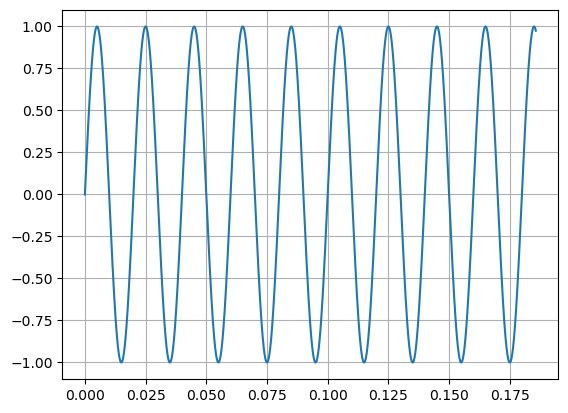

In [7]:
plt.figure()
plt.plot(t.squeeze(),x[0])
plt.grid()
plt.show()

### create training data

In [8]:
input_length = 1024

np.random.seed(0)
n_samples_train = 10000

# randomize the phase
phases_train = np.random.uniform(0,0.7, n_samples_train)

# randomize the amplitude
periods_train = np.random.uniform(20, 200, n_samples_train) #This is porbably frequency

x, t = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=phases_train, period=periods_train, amplitude=1)

# create a pytorch tensor and store it on the desired device (cpu or cuda)
x_train = torch.tensor(x, dtype=torch.float32).to(device)



In [9]:
periods_train

array([154.68823663,  52.43648732,  90.02416602, ..., 100.36203686,
        84.82279049, 132.65959628])

In [9]:
x_train.shape

torch.Size([10000, 1024])

### initialize dataset and dataloader

In [10]:
dataset_train = torch.utils.data.TensorDataset(x_train, x_train)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=32, shuffle=True)

In [11]:
len(dataset_train)

10000

### create an autoencoder 
see https://en.wikipedia.org/wiki/Autoencoder

**Tasks**:
- sketch the network architecture
- what does torch.nn.Tanh() do?
- do we use an activation function for the output layer in this example? Why could this be the case?
- why do we implement a forward() function but no backward() function? 

In [12]:
class AE(torch.nn.Module):
	def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128,64,36]):
		super().__init__()
        
		self.encoder = torch.nn.Sequential(
			torch.nn.Linear(input_dim, hidden_dims[0]),
			torch.nn.Tanh(),
			torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
			torch.nn.Tanh(),
			torch.nn.Linear(hidden_dims[1], hidden_dims[2]),
			torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2],latent_dim),
            torch.nn.Tanh(),
        )

		self.decoder = torch.nn.Sequential(
			torch.nn.Linear(latent_dim, hidden_dims[2]),
			torch.nn.Tanh(),
			torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
			torch.nn.Tanh(),
			torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
			torch.nn.Tanh(),
			torch.nn.Linear(hidden_dims[0], input_dim),
		)

	def forward(self, x):
		encoded = self.encoder(x)
		decoded = self.decoder(encoded)
		return decoded


In [13]:
autoencoder = AE(input_dim=input_length, latent_dim=2, hidden_dims=[256,64,32]).to(device)

### initialize the loss function and the optimizer
**Tasks**:
- write down the loss function in mathematical terms
- write down the optimizer's update rules in mathematical terms
- what's the difference between Adam and SGD?

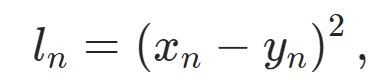

In [14]:
loss_function = torch.nn.MSELoss()

optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

### Train the Autoencoder

**Tasks**:
- for how many epochs do we train?
- what's the number of training steps per epoch?
- what's the batch size?
- explain the five steps of "Training step" in the code below

Epoch 0


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.4426


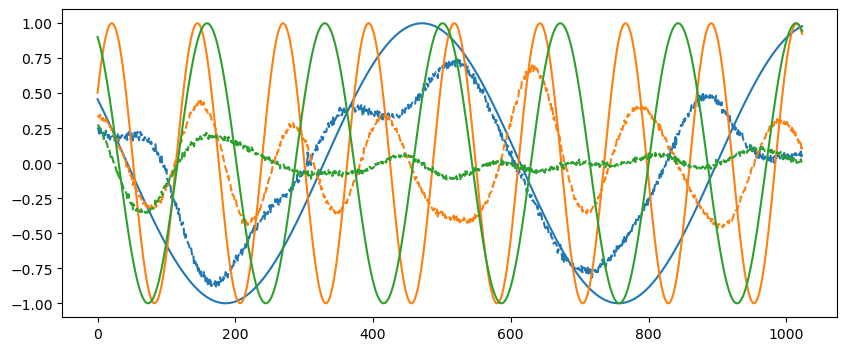

Epoch 1


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.4073
Epoch 2


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.3689
Epoch 3


...

loss: 0.3305
Epoch 4


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.3158
Epoch 5


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.3042


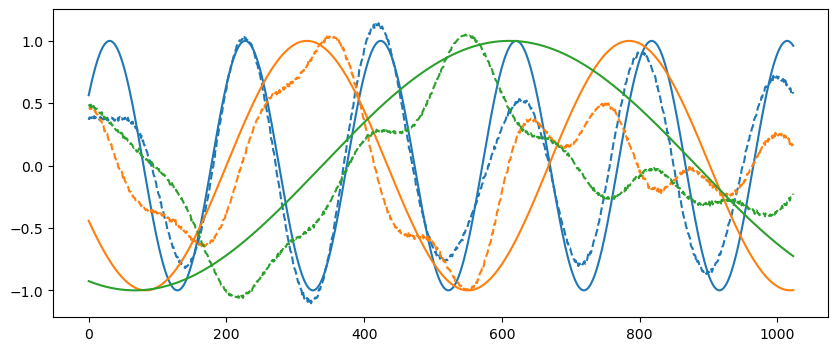

Epoch 6


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.2890
Epoch 7


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.2690
Epoch 8


...

loss: 0.2524
Epoch 9


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.2334
Epoch 10


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.2108


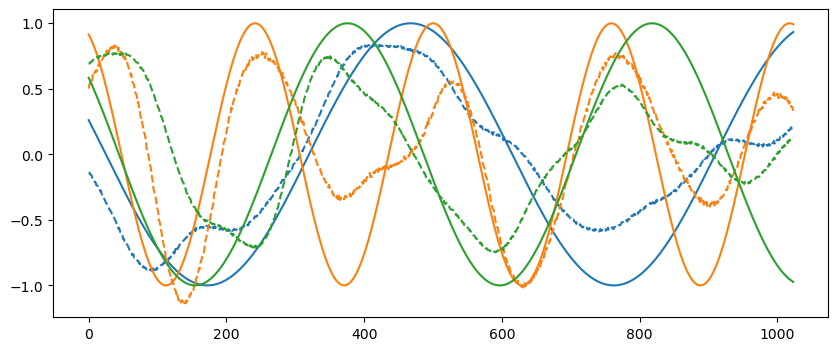

Epoch 11


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1975
Epoch 12


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1852
Epoch 13


...

loss: 0.1778
Epoch 14


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1708
Epoch 15


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1669


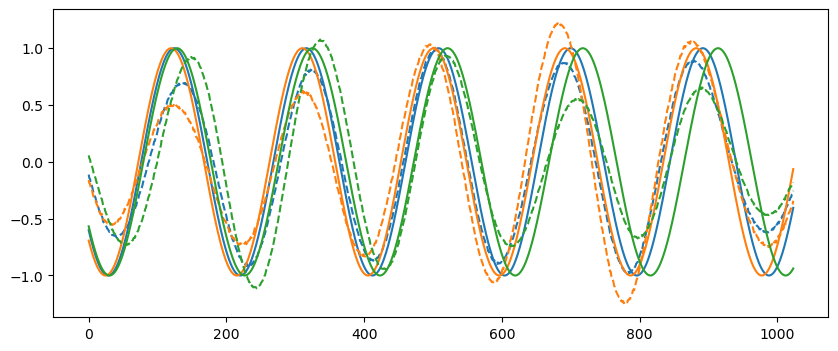

Epoch 16


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1660
Epoch 17


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1685
Epoch 18


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1609
Epoch 19


  0%|          | 0/313 [00:00<?, ?it/s]

loss: 0.1512


In [15]:
plot_freq=5

losses = []
for epoch in range(20):
    losses_epoch = []
    print("Epoch %i"%(epoch))
    for (data,_) in tqdm(dataloader_train):

        # Training step
        ###########################################
        optim.zero_grad()
        output = autoencoder(data)
        loss = loss_function(output, data)        
        loss.backward()
        optim.step()
        ###########################################
        
        losses_epoch.append(loss.cpu().detach().numpy())

    losses.append(np.mean(losses_epoch))
    print("loss: %.4f"%(losses[-1]))

    if epoch%plot_freq == 0:
        plt.figure(figsize=(10,4))
        plt.plot(data[0].cpu().detach().numpy(), color='tab:blue', linestyle='-')
        plt.plot(output[0].cpu().detach().numpy(), color='tab:blue', linestyle='--')
    
        plt.plot(data[1].cpu().detach().numpy(), color='tab:orange', linestyle='-')
        plt.plot(output[1].cpu().detach().numpy(), color='tab:orange', linestyle='--')
    
        plt.plot(data[2].cpu().detach().numpy(), color='tab:green', linestyle='-')
        plt.plot(output[2].cpu().detach().numpy(), color='tab:green', linestyle='--')    
        plt.show()
        

### investigate AE bottleneck

**Tasks**:
- what's the dimensionality of the autoencoder "bottleneck"?
- does the encoder capture semantically meaningful representations of phase and period?

In [16]:
bottleneck_features = autoencoder.encoder(x_train).cpu().detach().numpy()

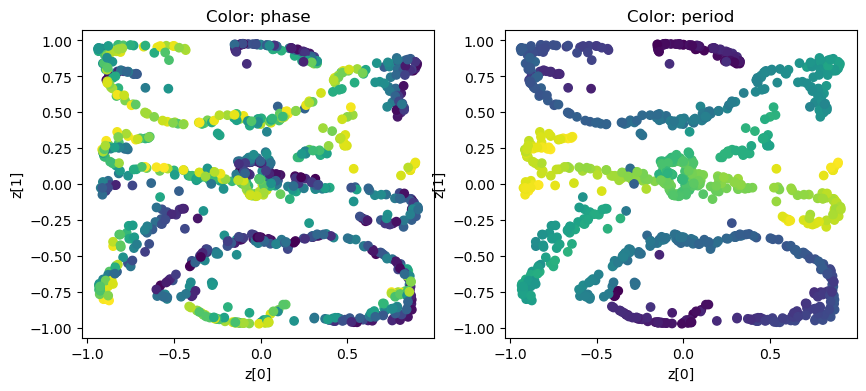

In [17]:
n_plot=1000

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].scatter(bottleneck_features[:n_plot,0], bottleneck_features[:n_plot,1], c=phases_train[:n_plot])
ax[1].scatter(bottleneck_features[:n_plot,0], bottleneck_features[:n_plot,1], c=periods_train[:n_plot])

ax[0].set_xlabel("z[0]")
ax[0].set_ylabel("z[1]")
ax[0].set_title("Color: phase")

ax[1].set_xlabel("z[0]")
ax[1].set_ylabel("z[1]")
ax[1].set_title("Color: period")

plt.show()

# Encoding of different shapes

In [18]:
input_length = 256

np.random.seed(0)
n_samples_train = 100000

periods_train = np.random.uniform(100, 500, n_samples_train)

x_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train[0*n_samples_train//4:1*n_samples_train//4], amplitude=1)
x_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train[1*n_samples_train//4:2*n_samples_train//4], amplitude=1)
x_tri, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train[2*n_samples_train//4:3*n_samples_train//4], amplitude=1)
x_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train[3*n_samples_train//4:4*n_samples_train//4], amplitude=1)

x_train = torch.tensor(np.concatenate([x_sin, x_saw, x_tri, x_square], axis=0), dtype=torch.float32)
shapes_train = np.arange(n_samples_train) // (n_samples_train//4)


In [19]:
shuffle_indices = np.random.permutation(np.arange(n_samples_train))

x_train_shuffle = x_train[shuffle_indices]
shapes_train_shuffle = shapes_train[shuffle_indices]
periods_train_shuffle = periods_train[shuffle_indices]

In [20]:
x_train.shape

torch.Size([100000, 256])

In [21]:
dataset_train = torch.utils.data.TensorDataset(x_train, x_train)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=32, shuffle=True)

In [22]:
autoencoder = AE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])

In [23]:
loss_function = torch.nn.MSELoss()

optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=3, threshold=1e-3, verbose=True)

**Task**:
- how does a learning rate scheduler work?
- why is it beneficial to use a learning rate scheduler?
- why don't we call the learning rate scheduler after every training step (= after every minibatch)?

Epoch 0


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.1288


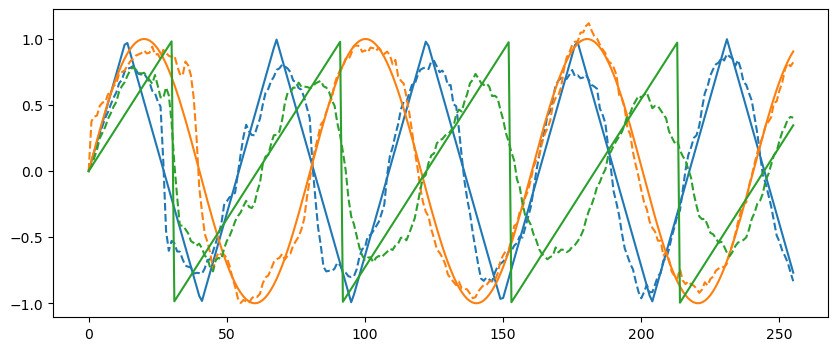

Epoch 1


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0662
Epoch 2


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0559
Epoch 3


...

loss: 0.0439
Epoch 4


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0376
Epoch 5


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0325


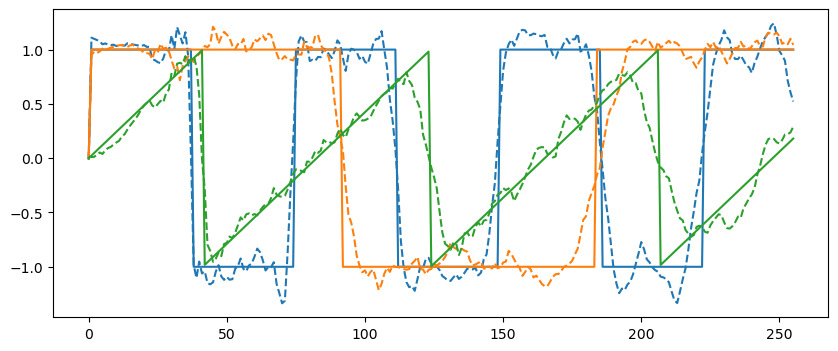

Epoch 6


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0284
Epoch 7


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0263
Epoch 8


...

loss: 0.0240
Epoch 9


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0237
Epoch 10


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0314


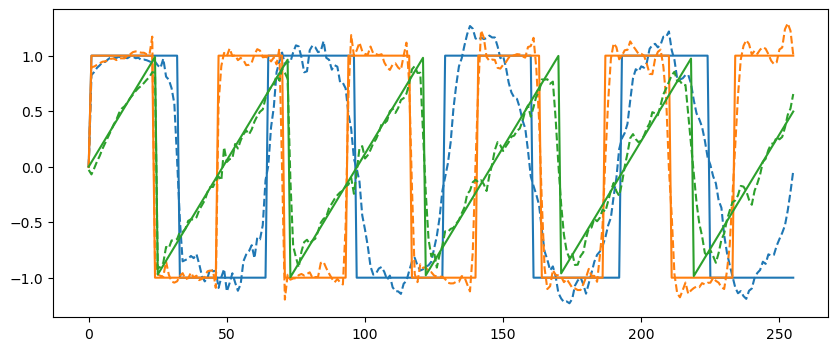

Epoch 11


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0399
Epoch 12


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0350
Epoch 13


  0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 00014: reducing learning rate of group 0 to 1.0000e-04.
loss: 0.0327
Epoch 14


  0%|          | 0/3125 [00:00<?, ?it/s]

loss: 0.0230


In [24]:
plot_freq=5

losses = []
for epoch in range(15):
    losses_epoch = []
    print("Epoch %i"%(epoch))
    for (data,_) in tqdm(dataloader_train):

        optim.zero_grad()
        output = autoencoder(data)
        loss = loss_function(output, data)
        loss.backward()
        optim.step()

        losses_epoch.append(loss.detach().numpy())
    scheduler.step(np.mean(losses_epoch))

    losses.append(np.mean(losses_epoch))
    print("loss: %.4f"%(losses[-1]))

    if epoch%plot_freq == 0:
        plt.figure(figsize=(10,4))
        plt.plot(data[0].detach().numpy(), color='tab:blue', linestyle='-')
        plt.plot(output[0].detach().numpy(), color='tab:blue', linestyle='--')
    
        plt.plot(data[1].detach().numpy(), color='tab:orange', linestyle='-')
        plt.plot(output[1].detach().numpy(), color='tab:orange', linestyle='--')
    
        plt.plot(data[2].detach().numpy(), color='tab:green', linestyle='-')
        plt.plot(output[2].detach().numpy(), color='tab:green', linestyle='--')    
        plt.show()
        

### investigate AE bottleneck

(100000, 2)


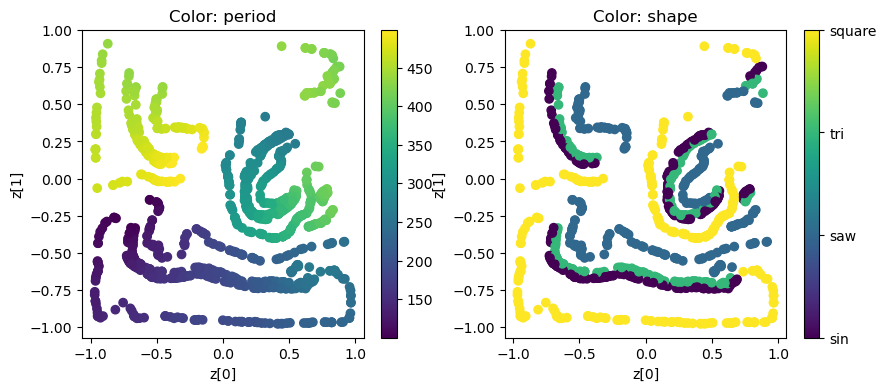

In [25]:
bottleneck_features = autoencoder.encoder(x_train_shuffle).detach().numpy()
print(bottleneck_features.shape)
n_plot=1000

fig, ax = plt.subplots(1,2, figsize=(10,4))

im0 = ax[0].scatter(bottleneck_features[:n_plot,0], bottleneck_features[:n_plot,1], c=periods_train_shuffle[:n_plot])
im1 = ax[1].scatter(bottleneck_features[:n_plot,0], bottleneck_features[:n_plot,1], c=shapes_train_shuffle[:n_plot])

ax[0].set_xlabel("z[0]")
ax[0].set_ylabel("z[1]")
ax[0].set_title("Color: period")

ax[1].set_xlabel("z[0]")
ax[1].set_ylabel("z[1]")
ax[1].set_title("Color: shape")

plt.colorbar(im0, ax=ax[0])
cbar = plt.colorbar(im1, ax=ax[1], ticks=[0, 1, 2, 3])

cbar.ax.set_yticklabels(["sin", "saw", "tri", "square"])

plt.show()

### Interpolate in the embedding space and decode
**Tasks**:
- what could we expect from interpolation in the embedding space?
- why don't we get a meaningful decoder output from an interpolated embedding vector?
- Overlay the AE embedding vectors z1, z2, zMean with the figure above!

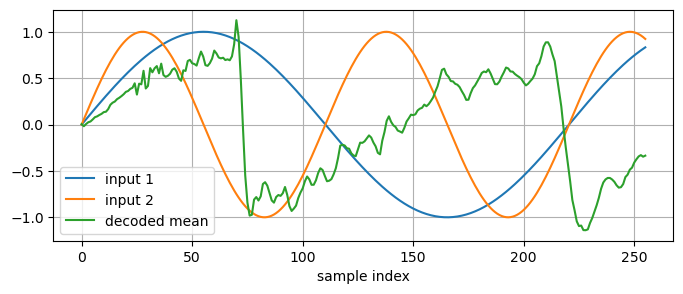

In [26]:
x1, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=100, amplitude=1)
x2, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=200, amplitude=1)

z1 = autoencoder.encoder(torch.Tensor(x1))
z2 = autoencoder.encoder(torch.Tensor(x2))

zMean = (z1+z2)/2

yMean = autoencoder.decoder(zMean)

plt.figure(figsize=(8,3))
plt.plot(x1[0], label='input 1')
plt.plot(x2[0], label='input 2')
plt.plot(yMean[0].detach().numpy(), label='decoded mean')
plt.grid()
plt.xlabel("sample index")
plt.legend()
plt.show()

In [ ]:
z_std = np.exp(0.5 * z_log_var[:,1].detach().numpy())

# Generate samples from the Gaussian distribution
samples = np.random.normal(loc=z_mean[:,1].detach().numpy(), scale=z_std, size=(n_plot, len(z_mean[:,1].detach().numpy())))

plt.figure(figsize=(8, 6))

# Plot histograms for each dimension
for i in range(len(z_mean)):
    plt.subplot(1, len(z_mean), i + 1)
    plt.hist(samples[:, i], bins=30, density=True, alpha=0.7, color='blue')
    plt.xlabel(f'z[{i}]')
    plt.ylabel('Density')
    plt.title(f'Distribution of z[{i}]')

plt.tight_layout()
plt.show()